<a href="https://colab.research.google.com/github/dewshishir/S_M/blob/main/Skill_Morph_Tree_Based_Ensembles_ML_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skill Morph Tree-Based Ensembles ML
**Instructor:** Md. Samiul Islam, Skill Morph Research Lab  
**Objective:** Build a simple machine learning model to predict Titanic passenger survival

## Cell 1: Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


## Cell 2: Mount Google Drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3: Load Training Data

In [2]:
# Load the training dataset from Google Drive
train_df = pd.read_csv('/content/train.csv')

# Display first few rows
print(f"Dataset shape: {train_df.shape}")
train_df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Cell 4: Data Preprocessing

In [3]:
# Drop unnecessary columns
train_df = train_df.drop(['Name', 'Ticket', 'Cabin'], axis=1)

# Fill missing Age with median
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

# Fill missing Embarked with mode
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Convert Sex to numeric (male=0, female=1)
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode Embarked
train_df = pd.get_dummies(train_df, columns=['Embarked'])

print("Preprocessing complete!")
print(f"Final shape: {train_df.shape}")
train_df.head()

Preprocessing complete!
Final shape: (891, 11)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,False,False,True
1,2,1,1,1,38.0,1,0,71.2833,True,False,False
2,3,1,3,1,26.0,0,0,7.9250,False,False,True
3,4,1,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,0,35.0,0,0,8.0500,False,False,True


## Cell 5: Split Data into Train/Validation Sets

In [4]:
# Separate features (X) and target (y)
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# Split into training and validation sets (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=20)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

Training set size: 712
Validation set size: 179


## Cell 6: Train Random Forest Classifier

In [5]:
# Create and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=20)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_val)

# Calculate metrics
rf_accuracy = accuracy_score(y_val, rf_predictions)
rf_precision = precision_score(y_val, rf_predictions)
rf_recall = recall_score(y_val, rf_predictions)
rf_f1 = f1_score(y_val, rf_predictions)

print("Random Forest Classifier Results:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

Random Forest Classifier Results:
Accuracy:  0.7989
Precision: 0.7818
Recall:    0.6418
F1 Score:  0.7049


## Cell 7: Train Extra Trees Classifier

In [6]:
# Create and train Extra Trees model
et_model = ExtraTreesClassifier(n_estimators=200, max_depth=4, random_state=42)
et_model.fit(X_train, y_train)

# Make predictions
et_predictions = et_model.predict(X_val)

# Calculate metrics
et_accuracy = accuracy_score(y_val, et_predictions)
et_precision = precision_score(y_val, et_predictions)
et_recall = recall_score(y_val, et_predictions)
et_f1 = f1_score(y_val, et_predictions)

print("Extra Trees Classifier Results:")
print(f"Accuracy:  {et_accuracy:.4f}")
print(f"Precision: {et_precision:.4f}")
print(f"Recall:    {et_recall:.4f}")
print(f"F1 Score:  {et_f1:.4f}")

Extra Trees Classifier Results:
Accuracy:  0.8156
Precision: 0.9250
Recall:    0.5522
F1 Score:  0.6916


## Cell 8: Compare Model Performance

In [7]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Extra Trees'],
    'Accuracy': [rf_accuracy, et_accuracy],
    'Precision': [rf_precision, et_precision],
    'Recall': [rf_recall, et_recall],
    'F1 Score': [rf_f1, et_f1]
})

print("Model Performance Comparison:")
print(comparison_df.to_string(index=False))

Model Performance Comparison:
        Model  Accuracy  Precision   Recall  F1 Score
Random Forest  0.798883   0.781818 0.641791  0.704918
  Extra Trees  0.815642   0.925000 0.552239  0.691589


## Cell 9: Generate Submission File

In [8]:
# Load test data
test_df = pd.read_csv('/content/test.csv')
passenger_ids = test_df['PassengerId']

# Apply same preprocessing to test data
test_df = test_df.drop(['Name', 'Ticket', 'Cabin'], axis=1)
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df = pd.get_dummies(test_df, columns=['Embarked'])

# To fix the error, we must match the features used during training.
# Since 'PassengerId' was included in the training set (Cell 5), we keep it here.
test_features = test_df

# Make predictions using Random Forest
predictions = rf_model.predict(test_features)

# Create submission file
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file created successfully!")
print(f"Total predictions: {len(submission)}")
print("\nFirst few predictions:")
print(submission.head())

# Download the file (in Google Colab)
from google.colab import files
files.download('submission.csv')

Submission file created successfully!
Total predictions: 418

First few predictions:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 10: Confusion Matrix Visualization

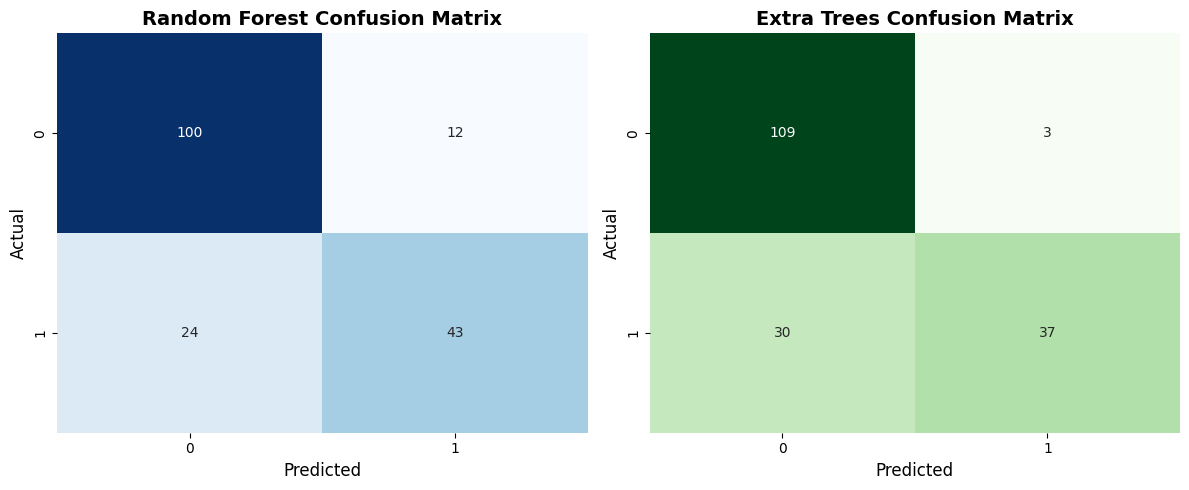

In [9]:
# Create confusion matrices
rf_cm = confusion_matrix(y_val, rf_predictions)
et_cm = confusion_matrix(y_val, et_predictions)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Extra Trees Confusion Matrix
sns.heatmap(et_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Extra Trees Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

# 🎯 Assignment — Random Forest vs Extra Trees

## Objective
Understand how tree-based ensemble models behave by experimenting with model parameters.

---

## Task — Model Experiment

Using the Titanic dataset already loaded in the notebook:

Change the following parameters for BOTH models:

- `n_estimators = 100, 300, 500`
- `max_depth = 3, 5`

Train the models again and observe the results.

---

## Questions

1. Which model performed better — Random Forest or Extra Trees?
2. Does increasing the number of trees always improve accuracy?
3. What happens when `max_depth` is small?

---

## 📊 Submission

Submit:

✅ Your notebook and Report

---




In [10]:
# Parameter values
n_estimators_list = [100, 300, 500]
max_depth_list = [3, 5]

results = []

for n in n_estimators_list:
    for depth in max_depth_list:

        # Random Forest
        rf_model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=20
        )
        rf_model.fit(X_train, y_train)
        rf_pred = rf_model.predict(X_val)
        rf_acc = accuracy_score(y_val, rf_pred)

        # Extra Trees
        et_model = ExtraTreesClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=20
        )
        et_model.fit(X_train, y_train)
        et_pred = et_model.predict(X_val)
        et_acc = accuracy_score(y_val, et_pred)

        results.append({
            "n_estimators": n,
            "max_depth": depth,
            "Random Forest Accuracy": rf_acc,
            "Extra Trees Accuracy": et_acc
        })

results_df = pd.DataFrame(results)

print("Experiment Results:")
results_df

Experiment Results:


,n_estimators,max_depth,Random Forest Accuracy,Extra Trees Accuracy
0,100,3,0.826816,0.815642
1,100,5,0.837989,0.821229
2,300,3,0.832402,0.810056
3,300,5,0.832402,0.821229
4,500,3,0.826816,0.810056
5,500,5,0.832402,0.821229


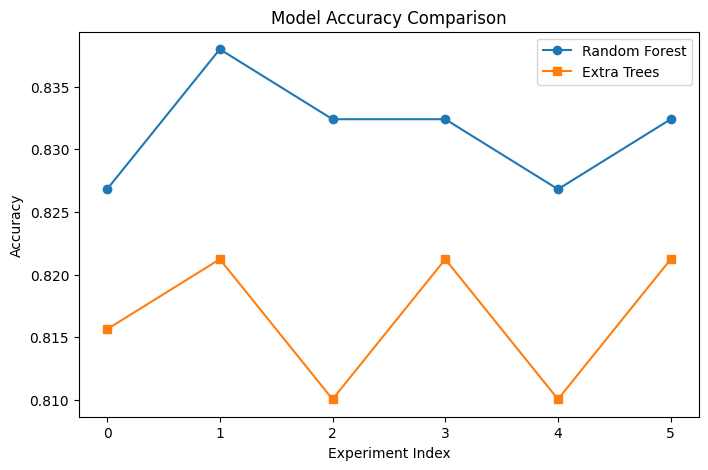

In [11]:
plt.figure(figsize=(8,5))

plt.plot(results_df["Random Forest Accuracy"], marker='o', label="Random Forest")
plt.plot(results_df["Extra Trees Accuracy"], marker='s', label="Extra Trees")

plt.title("Model Accuracy Comparison")
plt.xlabel("Experiment Index")
plt.ylabel("Accuracy")
plt.legend()

plt.show()